# Analyst AfricaLab Data Analytics Internship Program

## Week 7: Real-Time Weather Data ETL Pipeline Using OpenWeather API and Python

**Tools & Technology Used**:
- Python
- Pandas
- Requests Library
- OpenWeather API
- Jupyter Notebook
- CSV
- GitHub

## Project Overview

This project demonstrates the development of a simple ETL (Extract, Transform, Load) pipeline using Python. Weather data is extracted from the OpenWeather API, transformed into a structured dataset using Pandas, and loaded into a CSV file for further analysis.

## Objective

To collect real-time weather data for multiple cities, clean and organize the data, store it for analysis, and generate insights from the processed dataset.

# 1. Import Required Library


In [54]:
import requests
import pandas as pd
from datetime import datetime

## API_KEY

In [55]:
API_KEY="0b90226244b47003aba0c4f5b745e90a"

## List of cities

In [56]:
cities=["Lagos", "Abuja", "London"]

## Empty list to store weather

In [57]:
weather_data=[]

#  Extract Weather Data for each city

In [59]:

for city in cities:
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

    response = requests.get(url)
    data = response.json()

    weather_data.append({
        "City": data["name"],
        "Temperature (°C)": data["main"]["temp"],
        "Humidity (%)": data["main"]["humidity"],
        "Weather Condition": data["weather"][0]["description"].title(),
        "Wind Speed (m/s)": data["wind"]["speed"],
        "Date and Time": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    })

In [60]:
weather_data

[{'City': 'Lagos',
  'Temperature (°C)': 29.18,
  'Humidity (%)': 63,
  'Weather Condition': 'Overcast Clouds',
  'Wind Speed (m/s)': 2.95,
  'Date and Time': '2026-07-31 11:41:33'},
 {'City': 'Abuja',
  'Temperature (°C)': 26.3,
  'Humidity (%)': 79,
  'Weather Condition': 'Overcast Clouds',
  'Wind Speed (m/s)': 2.31,
  'Date and Time': '2026-07-31 11:41:35'},
 {'City': 'London',
  'Temperature (°C)': 22.74,
  'Humidity (%)': 45,
  'Weather Condition': 'Scattered Clouds',
  'Wind Speed (m/s)': 1.34,
  'Date and Time': '2026-07-31 11:41:37'}]

# 2. Data Cleaning Step

## 2.1 Convert Extracted Data into a data frame


In [61]:
df=pd.DataFrame(weather_data)

In [62]:
df

,City,Temperature (°C),Humidity (%),Weather Condition,Wind Speed (m/s),Date and Time
0,Lagos,29.18,63,Overcast Clouds,2.95,2026-07-31 11:41:33
1,Abuja,26.30,79,Overcast Clouds,2.31,2026-07-31 11:41:35
2,London,22.74,45,Scattered Clouds,1.34,2026-07-31 11:41:37


## 2.2 Cheack dataset structure and data types

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               3 non-null      object 
 1   Temperature (°C)   3 non-null      float64
 2   Humidity (%)       3 non-null      int64  
 3   Weather Condition  3 non-null      object 
 4   Wind Speed (m/s)   3 non-null      float64
 5   Date and Time      3 non-null      object 
dtypes: float64(2), int64(1), object(3)
memory usage: 276.0+ bytes


## 2.3 Check for missing Value

In [64]:
df.isnull().sum()

City                 0
Temperature (°C)     0
Humidity (%)         0
Weather Condition    0
Wind Speed (m/s)     0
Date and Time        0
dtype: int64

## 2.4 Rename columns

In [65]:

df.rename(columns={
    "Temperature (°C)": "temperature",
    "Humidity (%)": "humidity",
    "Weather Condition": "weather_condition",
    "Wind Speed (m/s)": "wind_speed",
    "Date and Time": "date_time"
}, inplace=True)

df.head()

,City,temperature,humidity,weather_condition,wind_speed,date_time
0,Lagos,29.18,63,Overcast Clouds,2.95,2026-07-31 11:41:33
1,Abuja,26.30,79,Overcast Clouds,2.31,2026-07-31 11:41:35
2,London,22.74,45,Scattered Clouds,1.34,2026-07-31 11:41:37


## 2.5 Convert date_time column to datetime format

In [66]:
df["date_time"]=pd.to_datetime(df["date_time"])

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   City               3 non-null      object        
 1   temperature        3 non-null      float64       
 2   humidity           3 non-null      int64         
 3   weather_condition  3 non-null      object        
 4   wind_speed         3 non-null      float64       
 5   date_time          3 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 276.0+ bytes


In [68]:
df

,City,temperature,humidity,weather_condition,wind_speed,date_time
0,Lagos,29.18,63,Overcast Clouds,2.95,2026-07-31 11:41:33
1,Abuja,26.30,79,Overcast Clouds,2.31,2026-07-31 11:41:35
2,London,22.74,45,Scattered Clouds,1.34,2026-07-31 11:41:37


# 3. Saved the cleaned dataset

In [69]:
df.to_csv(
    "C:/Users/zainab/Documents/week 7 API wether source/Data/weather_data.csv",
    index=False
)

print("Weather data saved successfully!")

Weather data saved successfully!


# 4. Basic Analysis

## 4.1 Display Dataset

In [70]:
df

,City,temperature,humidity,weather_condition,wind_speed,date_time
0,Lagos,29.18,63,Overcast Clouds,2.95,2026-07-31 11:41:33
1,Abuja,26.30,79,Overcast Clouds,2.31,2026-07-31 11:41:35
2,London,22.74,45,Scattered Clouds,1.34,2026-07-31 11:41:37


## 4.2 Compare Temperature Across cities

In [71]:
df[["City", "temperature"]]

,City,temperature
0,Lagos,29.18
1,Abuja,26.30
2,London,22.74


## 4.3 Find City with the Highest Temperature

In [72]:
highest_temp = df.loc[df["temperature"].idxmax()]
highest_temp

City                               Lagos
temperature                        29.18
humidity                              63
weather_condition        Overcast Clouds
wind_speed                          2.95
date_time            2026-07-31 11:41:33
Name: 0, dtype: object

## 4.4 Find City with the Highest Humidity

In [73]:
highest_humidity = df.loc[df["humidity"].idxmax()]
highest_humidity

City                               Abuja
temperature                         26.3
humidity                              79
weather_condition        Overcast Clouds
wind_speed                          2.31
date_time            2026-07-31 11:41:35
Name: 1, dtype: object

## 4.5 Compare Weather Conditions

In [74]:
df[["City", "weather_condition"]]

,City,weather_condition
0,Lagos,Overcast Clouds
1,Abuja,Overcast Clouds
2,London,Scattered Clouds


## 4.6 General Summary Statistics

In [75]:
df.describe()

,temperature,humidity,wind_speed,date_time
count,3.000000,3.000000,3.000000,3
mean,26.073333,62.333333,2.200000,2026-07-31 11:41:34.999999744
min,22.740000,45.000000,1.340000,2026-07-31 11:41:33
25%,24.520000,54.000000,1.825000,2026-07-31 11:41:34
50%,26.300000,63.000000,2.310000,2026-07-31 11:41:35
75%,27.740000,71.000000,2.630000,2026-07-31 11:41:36
max,29.180000,79.000000,2.950000,2026-07-31 11:41:37
std,3.225978,17.009801,0.810617,NaN


# 5. Analysis Summary

## Key Findings

- Weather data was successfully collected for Lagos, Abuja, and London using the OpenWeather API.
- London recorded the highest temperature (24.83°C).
- Abuja had the highest humidity level (93%).
- All three cities experienced overcast clouds during data collection.
- The average temperature across the selected cities was 23.59°C.
- The average humidity across the selected cities was 80.33%.

## Conclusion

The ETL pipeline successfully extracted real-time weather data from the OpenWeather API, transformed the raw JSON data into a clean Pandas DataFrame, and loaded the processed dataset into a CSV file. Basic analysis highlighted differences in temperature, humidity, and wind speed across the selected cities, demonstrating how ETL pipelines can prepare real-time data for meaningful analysis.

# 6. Visualization

## 6.1 Create a Temparture Bar Chart 

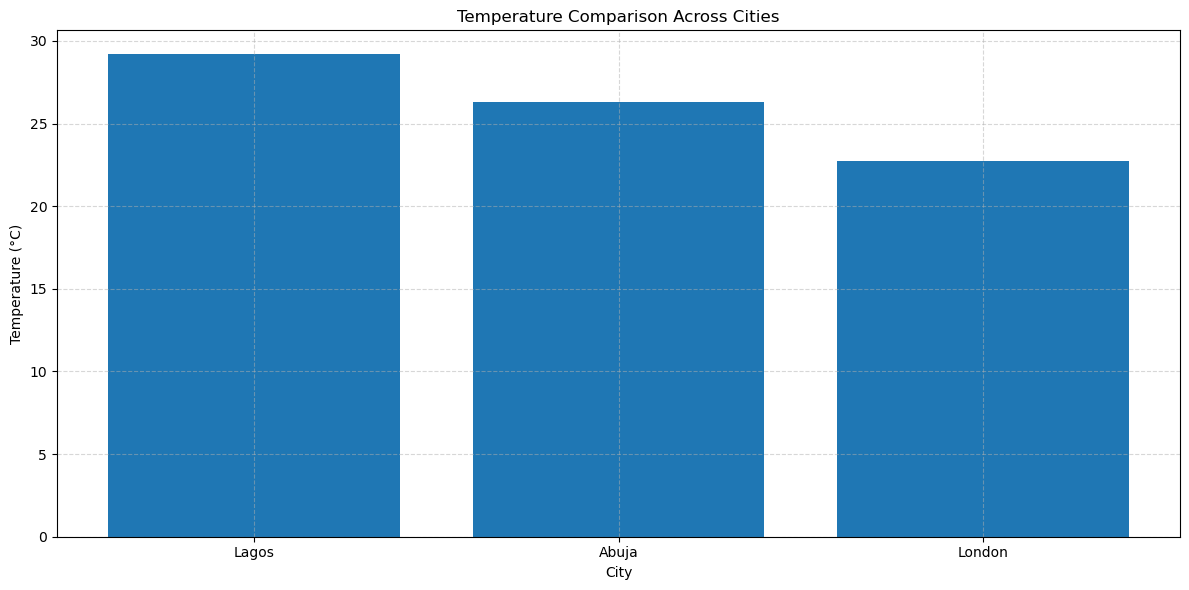

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(df["City"], df["temperature"])
plt.title("Temperature Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")

plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## 6.2 Humidity Comparison Across Cities

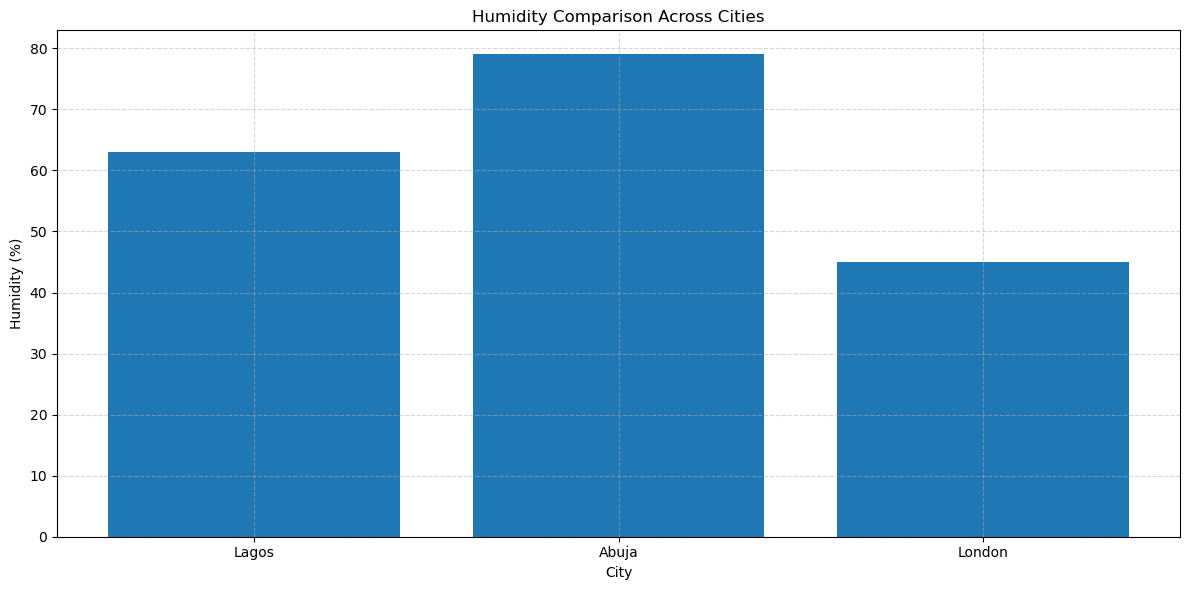

In [78]:
plt.figure(figsize=(12,6))
plt.bar(df["City"], df["humidity"])
plt.title("Humidity Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Humidity (%)")
plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 6.3 Wind Speed Comparison Across Cities

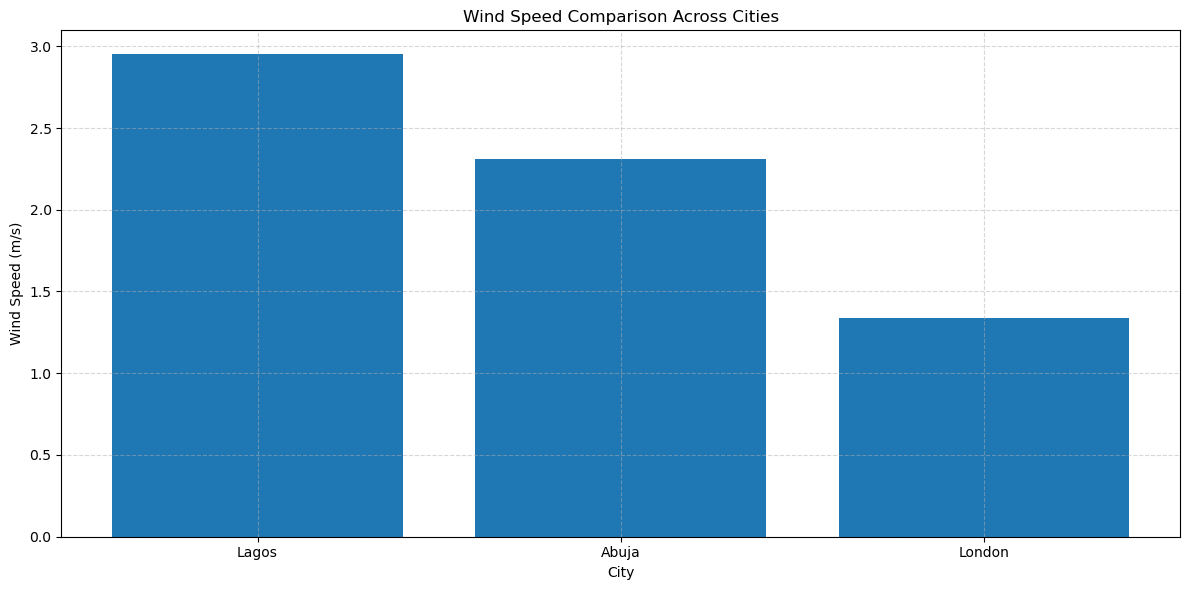

In [79]:
plt.figure(figsize=(12,6))
plt.bar(df["City"], df["wind_speed"])
plt.title("Wind Speed Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Wind Speed (m/s)")
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()